In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind

NOTEBOOK_DIR = Path.cwd()
DATA_PATH = NOTEBOOK_DIR / 'SI_results' / 'FigS2.csv'
OUTPUT_DIR = NOTEBOOK_DIR / 'SI_Figures'
OUTPUT_PATH = OUTPUT_DIR / 'FigS2.tiff'

LOCATIONS = ['Shanghai', 'Harbin']

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Cannot find worker-performance data: {DATA_PATH}')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# ===============================
# Global journal-style settings
# ===============================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'mathtext.fontset': 'cm',
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 2,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.major.width': 2,
    'ytick.major.width': 2,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
    'lines.solid_capstyle': 'round',
})


def hex_to_rgba(hex_color, alpha=1.0):
    hex_color = hex_color.lstrip('#')
    r, g, b = [int(hex_color[i:i + 2], 16) / 255 for i in (0, 2, 4)]
    return (r, g, b, alpha)


COLORS = {
    'Shanghai': hex_to_rgba('#DA4048', 0.4),
    'Harbin': hex_to_rgba('#BFD8EC', 0.2),
    'Shanghai_strip': hex_to_rgba('#DA4048', 0.2),
    'Harbin_strip': hex_to_rgba('#BFD8EC', 0.2),
}

METRIC_COLS = {
    'avg_delivery_time': r'$T_D$',
    'overtime_rate': r'$R_O$',
    'violation_pickup_rate': r'$R_{VP}$',
    'violation_delivery_rate': r'$R_{VD}$',
    'claim_rate': r'$R_C$',
    'avg_orders': r'$V_D$',
}

COL_TO_LATEX = {v: k for k, v in METRIC_COLS.items()}

In [3]:
def load_worker_performance(path):
    df = pd.read_csv(path)
    required_cols = {'location', 'class', *METRIC_COLS.keys()}
    missing_cols = required_cols.difference(df.columns)
    if missing_cols:
        raise ValueError(f'{path.name} is missing columns: {sorted(missing_cols)}')

    df = df.copy()
    df['location'] = pd.Categorical(df['location'], categories=LOCATIONS, ordered=True)
    for col in METRIC_COLS.keys():
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


final_df = load_worker_performance(DATA_PATH)
final_df.shape, final_df['class'].value_counts(), final_df['location'].value_counts()

((1083, 9),
 class
 Regular    975
 Elite      108
 Name: count, dtype: int64,
 location
 Harbin      552
 Shanghai    531
 Name: count, dtype: int64)

In [4]:
def build_relative_performance_data(df):
    elite_df = df[df['class'] == 'Elite'].copy()
    regular_df = df[df['class'] == 'Regular'].copy()

    if elite_df.empty:
        raise ValueError('No Elite riders found in the worker-performance data.')
    if regular_df.empty:
        raise ValueError('No Regular riders found in the worker-performance data.')

    for metric_col in METRIC_COLS.keys():
        regular_means = regular_df.groupby('location', observed=False)[metric_col].mean()

        def get_relative(row):
            city_mean = regular_means.get(row['location'])
            if pd.isna(city_mean) or city_mean == 0:
                return np.nan
            return row[metric_col] / city_mean

        elite_df[f'{metric_col}_rel'] = elite_df.apply(get_relative, axis=1)
        regular_df[f'{metric_col}_rel'] = regular_df.apply(get_relative, axis=1)

    plot_data = elite_df.melt(
        id_vars=['location'],
        value_vars=[f'{metric}_rel' for metric in METRIC_COLS.keys()],
        var_name='Metric_Key',
        value_name='Relative_Performance',
    )
    plot_data['Metric'] = plot_data['Metric_Key'].str.replace('_rel', '', regex=False).map(METRIC_COLS)
    return plot_data, regular_df


plot_data, regular_df = build_relative_performance_data(final_df)
plot_data.head(), plot_data.shape

(   location             Metric_Key  Relative_Performance Metric
 0  Shanghai  avg_delivery_time_rel              0.915028  $T_D$
 1  Shanghai  avg_delivery_time_rel              0.894917  $T_D$
 2  Shanghai  avg_delivery_time_rel              0.913806  $T_D$
 3  Shanghai  avg_delivery_time_rel              1.003582  $T_D$
 4  Shanghai  avg_delivery_time_rel              0.912482  $T_D$,
 (648, 4))

C:\Users\Administrator.DESKTOP-IME8OVA\AppData\Local\Temp\ipykernel_71464\4011600469.py:18: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


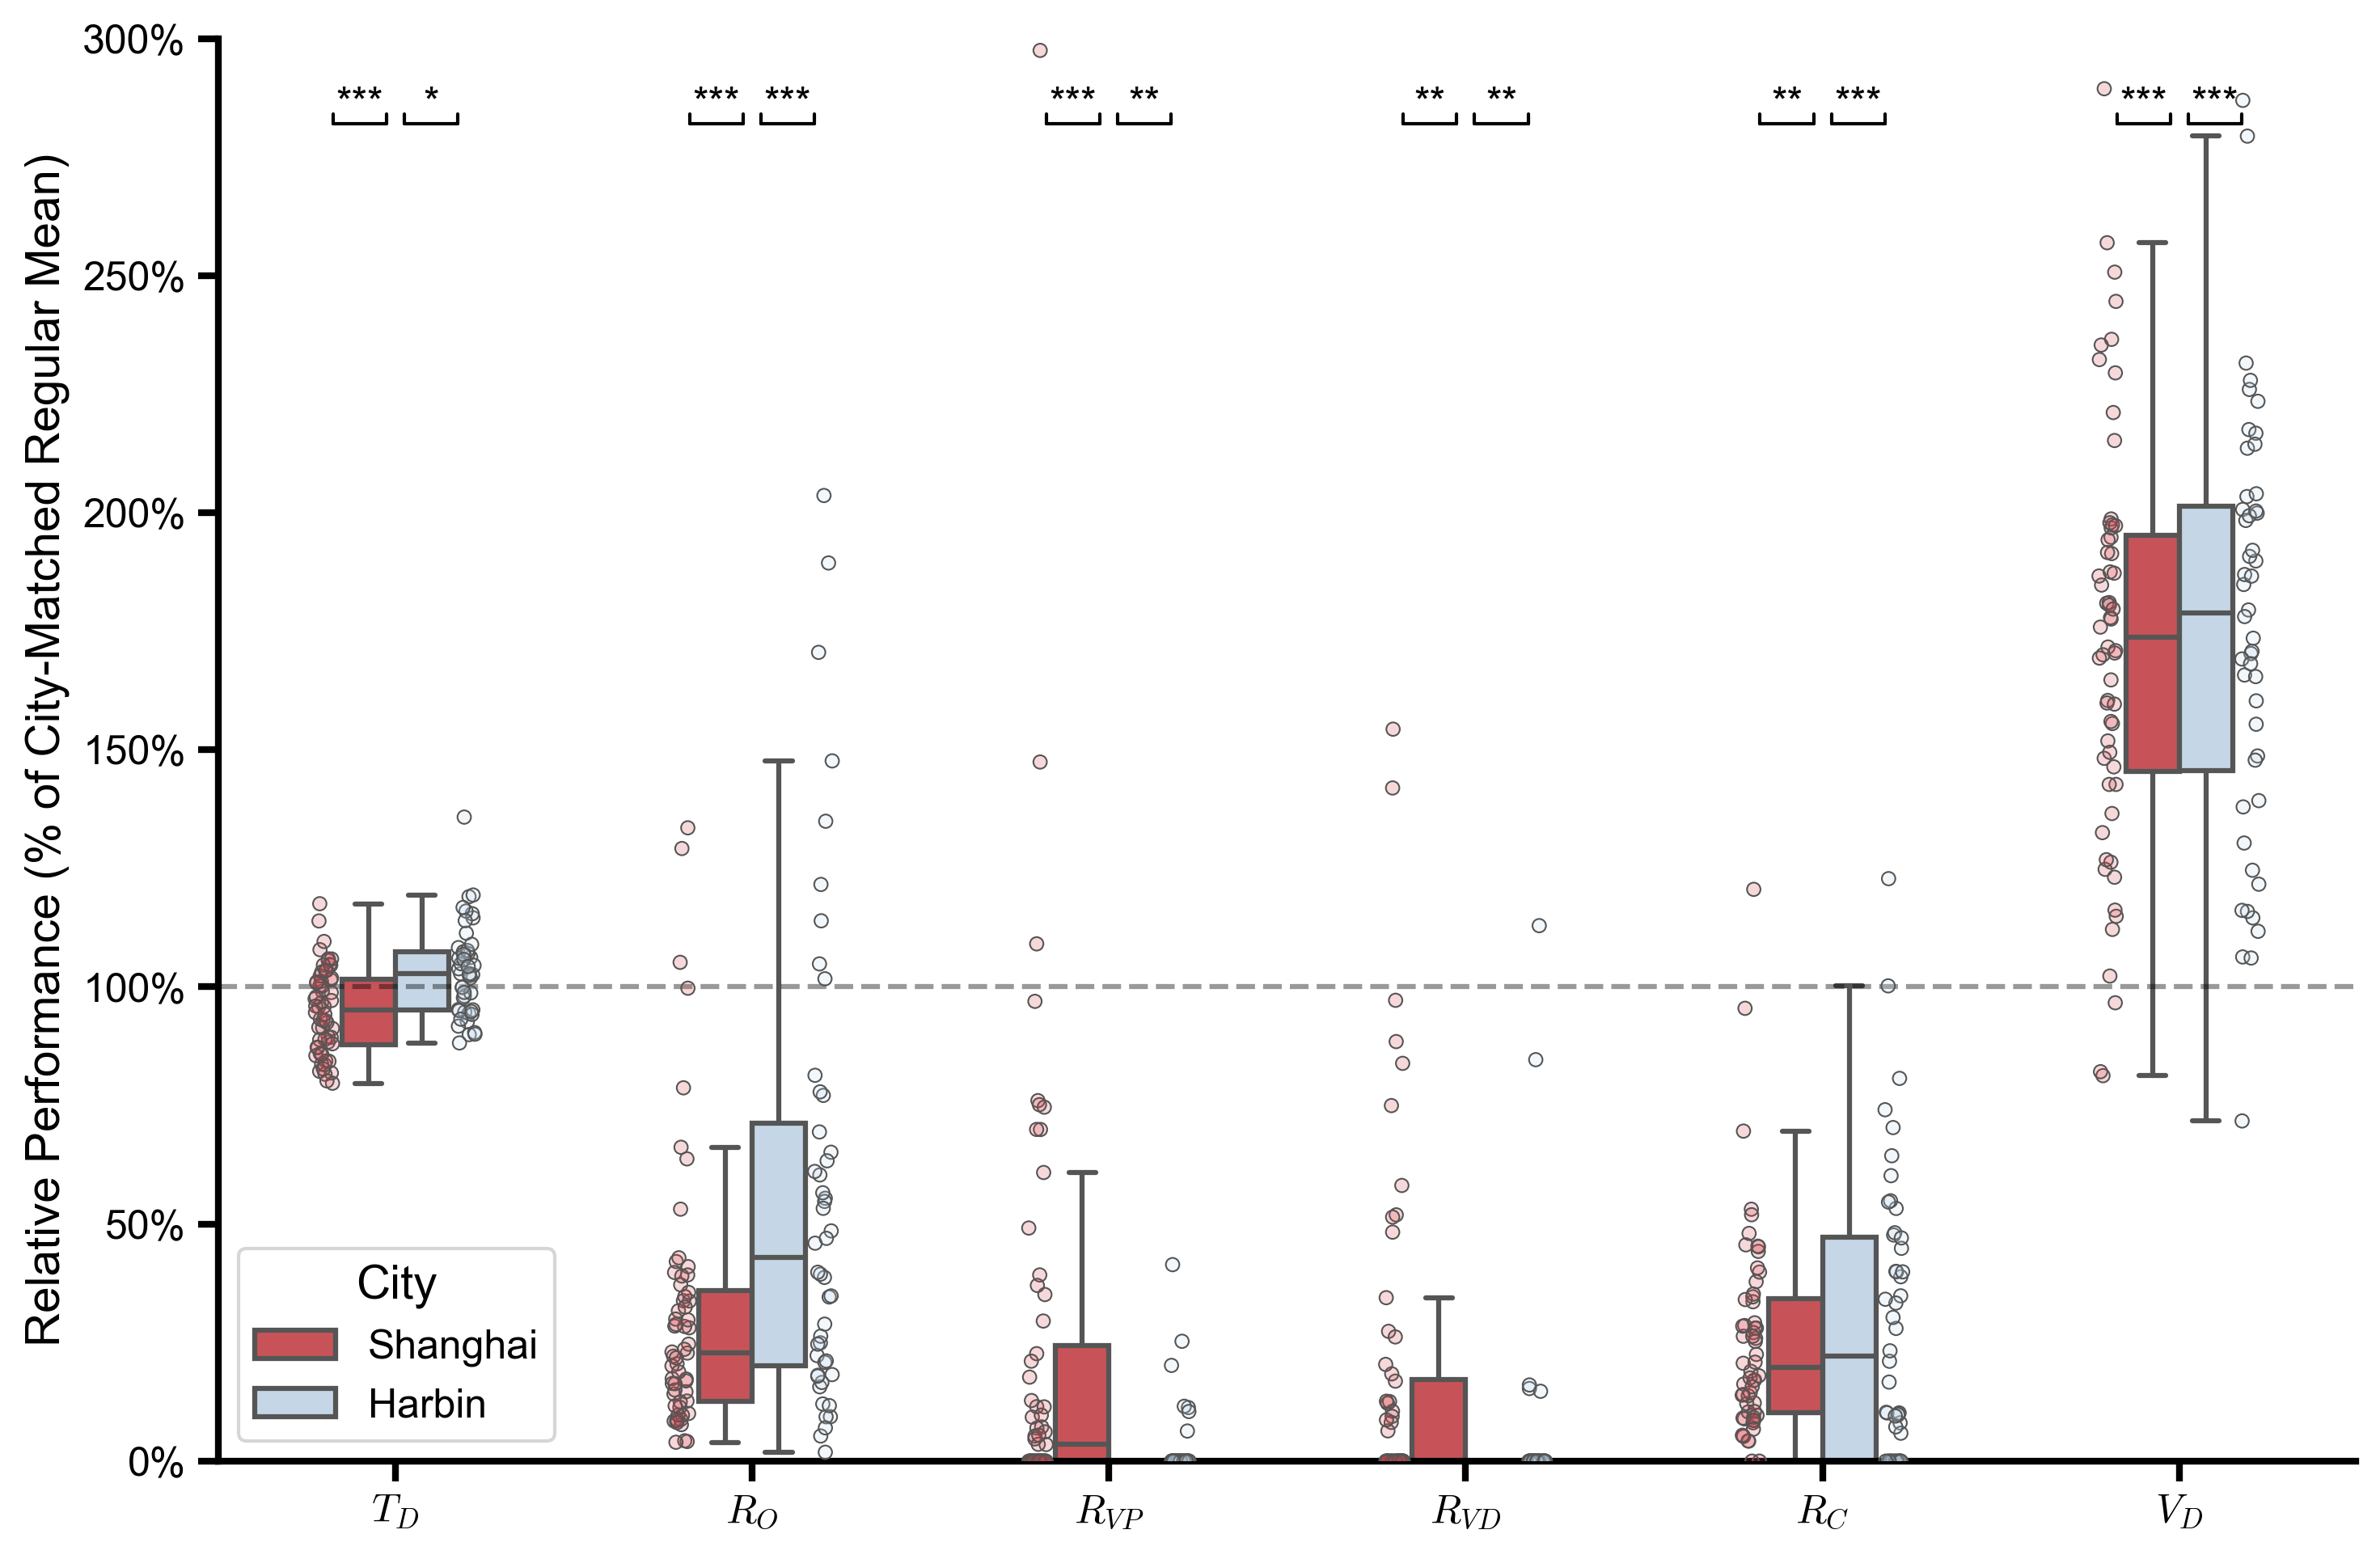

WindowsPath('d:/Final_Plot/Main Figures/SI_Figures/FigS2.tiff')

In [5]:
fig, ax = plt.subplots(figsize=(10, 6.6))

sns.boxplot(
    x='Metric',
    y='Relative_Performance',
    hue='location',
    data=plot_data,
    showfliers=False,
    width=0.3,
    palette={
        'Shanghai': COLORS['Shanghai'],
        'Harbin': COLORS['Harbin'],
    },
    linewidth=1.5,
    ax=ax,
)

sns.stripplot(
    x='Metric',
    y='Relative_Performance',
    hue='location',
    data=plot_data,
    dodge=True,
    jitter=0.05,
    size=4,
    palette={
        'Shanghai': COLORS['Shanghai_strip'],
        'Harbin': COLORS['Harbin_strip'],
    },
    edgecolor='gray',
    linewidth=0.5,
    ax=ax,
)

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.4)

ax.set_xlabel('')
ax.set_ylabel('Relative Performance (% of City-Matched Regular Mean)')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.set_ylim(0, 3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='City', frameon=True, shadow=False, prop={'size': 12})

y_sig_pos = 2.82
metrics_latex = list(METRIC_COLS.values())

for i, metric_latex in enumerate(metrics_latex):
    for j, loc in enumerate(LOCATIONS):
        e_vals = plot_data[
            (plot_data['Metric'] == metric_latex)
            & (plot_data['location'] == loc)
        ]['Relative_Performance'].dropna()
        eng_col = COL_TO_LATEX[metric_latex]
        r_vals = regular_df[regular_df['location'] == loc][f'{eng_col}_rel'].dropna()

        if len(e_vals) >= 2 and len(r_vals) >= 2:
            _, p_val = ttest_ind(e_vals, r_vals, equal_var=False)
            sig = 'ns'
            if p_val < 0.001:
                sig = '***'
            elif p_val < 0.01:
                sig = '**'
            elif p_val < 0.05:
                sig = '*'

            x_pos = i + (j - 0.5) * 0.2
            bracket_half_width = 0.075
            ax.text(x_pos, y_sig_pos, sig, ha='center', va='bottom', fontsize=12, color='black')
            ax.plot([x_pos - bracket_half_width, x_pos + bracket_half_width], [y_sig_pos, y_sig_pos], lw=1, color='black')
            ax.plot([x_pos - bracket_half_width, x_pos - bracket_half_width], [y_sig_pos, y_sig_pos + 0.02], lw=1, color='black')
            ax.plot([x_pos + bracket_half_width, x_pos + bracket_half_width], [y_sig_pos, y_sig_pos + 0.02], lw=1, color='black')

plt.tight_layout(pad=1.0)
fig.savefig(OUTPUT_PATH, format='tiff', dpi=600, bbox_inches='tight')
plt.show()
OUTPUT_PATH